# Data preprocessing

* Get monthly data from Ed's Rainfall Rescue project - put into sqlite for easy analysis
* Get daily data transcriptions from the Daily weather reports - also into sqlite.

# Get monthly data from Ed's Rainfall Rescue project

A key part of processing the daily rainfall data is to match it to the monthly rainfall data already digitised by Rainfall Rescue. The monthly data already has station locations and other metadata, so if we can match a daily record to a monthly one, we can use the metadata from the monthly data to enrich the daily data.

Start by cloning the Rainfall Rescue GitHub repository:

In [2]:
# Setup

import os
import subprocess

# Target location for the Rainfall Rescue repository
repo_dir = f"{os.getenv('PDIR')}/Rainfall-Rescue"

# Repository URL for Rainfall Rescue
repo_url = "git@github.com:ed-hawkins/rainfall-rescue.git"

In [2]:
# Clone the Rainfall Rescue repository if it doesn't already exist

if not os.path.exists(repo_dir):
    subprocess.run(["git", "clone", repo_url, repo_dir])

Cloning into '/data/scratch/philip.brohan/ADRQ/Rainfall-Rescue'...
Updating files: 100% (123722/123722), done.


## Build SQLite database from Rainfall Rescue CSV files

This performs a full rebuild of the SQLite database from combined files in `DATA` (excluding `TYRain_*.csv` source sheets).

In [3]:
from pathlib import Path

from src.rainfall_rescue_sqlite.ingest import default_db_path, ingest_combined_csvs

rainfall_rescue_root = Path(repo_dir)
db_path = default_db_path()

result = ingest_combined_csvs(
    rainfall_rescue_root=rainfall_rescue_root,
    db_path=db_path,
)

result

IngestionResult(db_path=PosixPath('/data/scratch/philip.brohan/ADRQ/Rainfall-Rescue/rainfall_rescue.sqlite'), source_root=PosixPath('/data/scratch/philip.brohan/ADRQ/Rainfall-Rescue/DATA'), files_discovered=8690, files_ingested=8690, station_rows=8690, monthly_rows=3374861, annual_rows=277250, errors=0)

In [4]:
import sqlite3

with sqlite3.connect(db_path) as conn:
    cur = conn.cursor()
    station_count = cur.execute("SELECT COUNT(*) FROM stations").fetchone()[0]
    monthly_count = cur.execute("SELECT COUNT(*) FROM monthly_rainfall").fetchone()[0]
    annual_count = cur.execute("SELECT COUNT(*) FROM annual_totals").fetchone()[0]

    print(f"Stations: {station_count}")
    print(f"Monthly rows: {monthly_count}")
    print(f"Annual rows: {annual_count}")

    sample = cur.execute(
        """
        SELECT s.location_name, m.year, m.month, m.rainfall_in
        FROM monthly_rainfall m
        JOIN stations s ON s.station_file_id = m.station_file_id
        WHERE s.location_name LIKE 'ABERPORTH%'
        ORDER BY m.year, m.month
        LIMIT 24
        """
    ).fetchall()

sample[:5]

Stations: 8690
Monthly rows: 3374861
Annual rows: 277250


[('ABERPORTH', 1941, 1, 2.94),
 ('ABERPORTH', 1941, 2, 2.72),
 ('ABERPORTH', 1941, 3, 3.0),
 ('ABERPORTH', 1941, 4, 1.33),
 ('ABERPORTH', 1941, 5, 2.02)]

In [5]:
# Retrieve station metadata for a few stations

with sqlite3.connect(db_path) as conn:
    conn.row_factory = sqlite3.Row
    cur = conn.cursor()

    stations = cur.execute(
        """
        SELECT
            station_file_id,
            location_name,
            station_number,
            grid_reference,
            longitude,
            latitude,
            elevation_ft,
            station_file_name,
            source_path
        FROM stations
        ORDER BY location_name
        LIMIT 5
        """
    ).fetchall()

for row in stations:
    print(
        f"{row['location_name']!s:<40}"
        f"  stn={row['station_number'] or 'n/a':<12}"
        f"  lat={row['latitude'] or 'n/a'!s:<10}"
        f"  lon={row['longitude'] or 'n/a'!s:<12}"
        f"  elev={row['elevation_ft'] or 'n/a'!s:<6} ft"
        f"  grid={row['grid_reference'] or 'n/a'}"
    )

1 MI FROM EDINBURGH                       stn=RR502         lat=55.94251    lon=-3.187925     elev=250    ft  grid=NT259728
63 BLOOMSBURY ST BIRMINGHAM               stn=RR1550        lat=52.4922     lon=-1.8731       elev=340    ft  grid=SP087882
ABBEY ST BATHANS, BERWICKSHIRE            stn=RR2226        lat=55.852382   lon=-2.3897074    elev=450    ft  grid=NT757622
ABBEY-CWMHIR-THE-HALL                     stn=4241/5        lat=52.330722   lon=-3.3881959    elev=877    ft  grid=SO055712
ABBEY-LEIX-BLANDSFORT                     stn=n/a           lat=52.930139   lon=-7.284667     elev=532    ft  grid=IS4814786802


# Get ensemble transcriptions of the Daily Rainfall images

The daily rainfall ensemble transcriptions are a *separate* data source, stored
in their own SQLite database (`ensemble_transcriptions.sqlite`). Each JSON file
holds keys `Day 1` .. `Day 31` plus a `Totals` block; every key maps to 12
month slots (January-December) and each month slot has 5 ensemble member values.

This section performs a full rebuild of that database from all JSON files in the
`ensemble_transcriptions` directory.


In [7]:
from src.rainfall_rescue_sqlite.ensemble_ingest import (
    default_ensemble_db_path,
    default_ensemble_root,
    ingest_ensemble_json,
)

ensemble_root = default_ensemble_root()
ensemble_db_path = default_ensemble_db_path()

# Full rebuild. Set max_files for a quick smoke run, e.g. max_files=50.
ensemble_result = ingest_ensemble_json(
    ensemble_root=ensemble_root,
    db_path=ensemble_db_path,
    max_files=None,
)

ensemble_result


EnsembleIngestionResult(db_path=PosixPath('/data/scratch/philip.brohan/ADRQ/ensemble_transcriptions.sqlite'), source_root=PosixPath('/data/scratch/philip.brohan/documents/Daily_Rainfall_UK/operational_sample/ensemble_transcriptions'), files_discovered=45990, files_ingested=45150, daily_rows=83979000, total_rows=2709000, errors=840)

In [8]:
import sqlite3

with sqlite3.connect(ensemble_db_path) as ens_conn:
    ens_cur = ens_conn.cursor()
    file_count = ens_cur.execute("SELECT COUNT(*) FROM ensemble_files").fetchone()[0]
    daily_count = ens_cur.execute("SELECT COUNT(*) FROM ensemble_daily_values").fetchone()[0]
    total_count = ens_cur.execute("SELECT COUNT(*) FROM ensemble_monthly_totals").fetchone()[0]

    print(f"Files: {file_count}")
    print(f"Daily value rows: {daily_count}")
    print(f"Monthly total rows: {total_count}")


Files: 45150
Daily value rows: 83979000
Monthly total rows: 2709000


In [9]:
# Sample daily ensemble values for one file (day 1, all months and members)

with sqlite3.connect(ensemble_db_path) as ens_conn:
    ens_conn.row_factory = sqlite3.Row
    ens_cur = ens_conn.cursor()

    file_row = ens_cur.execute(
        "SELECT file_id, file_name, year_start, year_end, descriptor, section_id, num_days "
        "FROM ensemble_files ORDER BY file_name LIMIT 1"
    ).fetchone()

    print(
        f"file_id={file_row['file_id']}  {file_row['file_name']}  "
        f"years={file_row['year_start']}-{file_row['year_end']}  "
        f"descriptor={file_row['descriptor']}  section={file_row['section_id']}  "
        f"days={file_row['num_days']}"
    )

    daily_sample = ens_cur.execute(
        """
        SELECT month, ensemble_member, rainfall
        FROM ensemble_daily_values
        WHERE file_id = ? AND day_of_month = 1
        ORDER BY month, ensemble_member
        """,
        (file_row["file_id"],),
    ).fetchall()

for r in daily_sample[:15]:
    print(f"  month={r['month']:>2}  member={r['ensemble_member']}  rainfall={r['rainfall']}")


file_id=1  DRain_1861-1870_Anglesey-3.json  years=None-None  descriptor=None  section=None  days=31
  month= 1  member=1  rainfall=None
  month= 1  member=2  rainfall=0.5
  month= 1  member=3  rainfall=None
  month= 1  member=4  rainfall=0.5
  month= 1  member=5  rainfall=None
  month= 2  member=1  rainfall=0.19
  month= 2  member=2  rainfall=0.14
  month= 2  member=3  rainfall=0.14
  month= 2  member=4  rainfall=0.16
  month= 2  member=5  rainfall=None
  month= 3  member=1  rainfall=0.3
  month= 3  member=2  rainfall=0.34
  month= 3  member=3  rainfall=0.34
  month= 3  member=4  rainfall=0.34
  month= 3  member=5  rainfall=None


In [10]:
# Monthly totals for the same file: mean ensemble total per month

with sqlite3.connect(ensemble_db_path) as ens_conn:
    ens_conn.row_factory = sqlite3.Row
    ens_cur = ens_conn.cursor()

    totals = ens_cur.execute(
        """
        SELECT month,
               AVG(total) AS mean_total,
               COUNT(total) AS n_values
        FROM ensemble_monthly_totals
        WHERE file_id = ?
        GROUP BY month
        ORDER BY month
        """,
        (file_row["file_id"],),
    ).fetchall()

for r in totals:
    mean_total = r["mean_total"]
    mean_str = f"{mean_total:.3f}" if mean_total is not None else "n/a"
    print(f"  month={r['month']:>2}  mean_total={mean_str:>8}  members_with_value={r['n_values']}")


  month= 1  mean_total=   4.410  members_with_value=4
  month= 2  mean_total=   3.459  members_with_value=5
  month= 3  mean_total=   1.798  members_with_value=5
  month= 4  mean_total=   1.602  members_with_value=5
  month= 5  mean_total=   2.565  members_with_value=5
  month= 6  mean_total=   1.523  members_with_value=5
  month= 7  mean_total=   0.992  members_with_value=5
  month= 8  mean_total=   1.104  members_with_value=5
  month= 9  mean_total=   0.394  members_with_value=5
  month=10  mean_total=   3.581  members_with_value=5
  month=11  mean_total=   3.576  members_with_value=5
  month=12  mean_total=   3.255  members_with_value=5


## Baseline similarity matching (RR monthly vs ensemble consensus)

Every daily transcription (ensemble file) is matched to the Rainfall-Rescue
monthly records by comparing 12-month rainfall *shapes*:

- **RR vectors**: station-year monthly profiles from `monthly_rainfall`
- **Ensemble vectors**: monthly consensus profile per file (median of the 5 members)
- **Similarity**: masked cosine over the overlapping months
- **Uncertainty**: mean monthly IQR, used as a small ranking penalty

The cell below runs this matcher **interactively on a small bounded slice**
(200 ensemble queries against 20,000 RR candidates) so the notebook stays fast.
The full cross-product (~45,000 ensemble files x ~285,000 RR station-years) is
far too large for one process, so the production run is done in parallel on the
SPICE cluster with SLURM - see the "Full-scale matching with SLURM" section below.

In [12]:
from pathlib import Path

from src.rainfall_rescue_sqlite.comparison_baseline import (
    build_comparison_vectors,
    run_baseline_matching,
)

comparison_db_path = Path(f"{os.getenv('PDIR')}/monthly_similarity.sqlite")

build_result = build_comparison_vectors(
    rr_db_path=db_path,
    ensemble_db_path=ensemble_db_path,
    comparison_db_path=comparison_db_path,
)

# Start with bounded sizes for interactive notebook use.
match_result = run_baseline_matching(
    comparison_db_path=comparison_db_path,
    top_k=10,
    min_overlap=10,
    uncertainty_weight=0.15,
    max_ensemble_queries=200,
    max_rr_candidates=20000,
)

print(build_result)
print(match_result)


BuildResult(comparison_db_path=PosixPath('/data/scratch/philip.brohan/ADRQ/monthly_similarity.sqlite'), rr_vectors=285146, ensemble_vectors=45150)
MatchResult(comparison_db_path=PosixPath('/data/scratch/philip.brohan/ADRQ/monthly_similarity.sqlite'), session_id=1, ensemble_queries=200, rr_candidates=20000, matches_written=1990)


In [16]:
# Inspect top matches from the latest similarity session

with sqlite3.connect(comparison_db_path) as cmp_conn:
    cmp_conn.row_factory = sqlite3.Row
    cmp_cur = cmp_conn.cursor()

    latest_session = cmp_cur.execute(
        "SELECT MAX(session_id) FROM similarity_sessions"
    ).fetchone()[0]

    rows = cmp_cur.execute(
        """
        SELECT
            m.query_rank,
            m.adjusted_score,
            m.cosine_similarity,
            m.overlap_months,
            m.ensemble_uncertainty,
            e.file_name,
            e.descriptor,
            r.station_file_id,
            r.year,
            r.location_name
        FROM similarity_matches m
        JOIN ensemble_consensus_vectors e ON e.ensemble_vector_id = m.ensemble_vector_id
        JOIN rr_monthly_vectors r ON r.rr_vector_id = m.rr_vector_id
        WHERE m.session_id = ?
        ORDER BY m.adjusted_score DESC
        LIMIT 20
        """,
        (latest_session,),
    ).fetchall()

print(f"Latest session: {latest_session}")
for row in rows:
    print(
        f"rank={row['query_rank']:>2}  score={row['adjusted_score']:.4f}  "
        f"cos={row['cosine_similarity']:.4f}  overlap={row['overlap_months']:>2}  "
        f"unc={row['ensemble_uncertainty'] if row['ensemble_uncertainty'] is not None else 'n/a'}  "
        f"ensemble={row['file_name']}  rr={row['station_file_id']}:{row['year']}  "
        f"loc={row['location_name'] or 'n/a'}"
    )


Latest session: 1
rank= 1  score=1.0000  cos=1.0000  overlap=12  unc=0.0  ensemble=DRain_1911-1920_RainNos_Kent_F-P-588.json  rr=TUNBRIDGE-WELLS-PEMBURY/TUNBRIDGE-WELLS-PEMBURY:1912  loc=TUNBRIDGE WELLS PEMBURY
rank= 1  score=1.0000  cos=1.0000  overlap=12  unc=0.0  ensemble=DRain_1911-1920_RainNos_Kent_F-P_B078-2.json  rr=TUNBRIDGE-WELLS-PEMBURY/TUNBRIDGE-WELLS-PEMBURY:1912  loc=TUNBRIDGE WELLS PEMBURY
rank= 1  score=1.0000  cos=1.0000  overlap=12  unc=0.0  ensemble=DRain_1911-1920_RainNos_Kent_R-W_B004-5.json  rr=RECULVER/RECULVER-2:1914  loc=RECULVER (HERNE-BAY)
rank= 1  score=1.0000  cos=1.0000  overlap=12  unc=0.0  ensemble=DRain_1911-1920_RainNos_London_A-H_Box_1_B035-8.json  rr=FINSBURY-NEW-RIVER-HEAD/FINSBURY-NEW-RIVER-HEAD:1918  loc=FINSBURY-NEW-RIVER-HEAD
rank= 1  score=1.0000  cos=1.0000  overlap=12  unc=0.0  ensemble=DRain_1911-1920_RainNos_London_P-W_Box_3_B039-7.json  rr=WANDSWORTH-PUTNEY-HEATH/WANDSWORTH-PUTNEY-HEATH:1917  loc=WANDSWORTH-PUTNEY-HEATH
rank= 1  score=1.000

## Full-scale matching with SLURM

The interactive baseline above only matches a small slice. To match **every**
ensemble file against **every** RR station-year we split the work into shards
and run them as a SLURM array job on the SPICE cluster.

**How the work is sharded**

- The ensemble queries are divided into `NUM_SHARDS` (default 100) contiguous
  slices. Each shard matches its own slice against *all* RR candidates and
  writes its top-K results to a private SQLite file (`shard_XXXXX.sqlite`).
- A final **merge** step reads all the shard files and writes them into a single
  `similarity_sessions` / `similarity_matches` session in `monthly_similarity.sqlite`.

**Pipeline (three stages, chained with `--dependency=afterok`)**

| Stage | Script | SLURM | Purpose |
|-------|--------|-------|---------|
| build | `scripts/slurm/build_vectors.sbatch` | 1 job | (re)build the comparison vectors DB |
| match | `scripts/slurm/match_array.sbatch`  | array `0-99` | run each shard in parallel |
| merge | `scripts/slurm/merge_shards.sbatch` | 1 job | combine shards into one session |

Resources, shard count and matching parameters are all set in
`scripts/slurm/config.sh` (quality-of-service, cores, memory and wall-time are
specified explicitly per stage via `--qos`, `--ntasks`, `--mem`, `--time`).

**Cluster-filesystem note.** SQLite can't do its POSIX write-locking on the
shared parallel filesystem, so the scripts read the source databases with
`immutable=1` and write every database on node-local `$TMPDIR`, copying the
finished file back to shared disc (`src/rainfall_rescue_sqlite/sqlite_staging.py`).

**Launch the whole pipeline** (from the repository root, on a login node):

```bash
scripts/slurm/submit_all.sh
```

**Monitor it**

```bash
squeue -u $USER                                              # queued / running
sacct --format=JobID%15,JobName%14,State,ExitCode,Elapsed   # final states
ls -t $PDIR/slurm_logs | head                               # per-job logs
```

The whole run completes in a few minutes. The cell below inspects the resulting
session in `monthly_similarity.sqlite`.

In [17]:
# Summarise the similarity sessions written to monthly_similarity.sqlite.
# After a full SLURM run this shows the single merged, full-scale session.

with sqlite3.connect(f"file:{comparison_db_path}?immutable=1", uri=True) as cmp_conn:
    cmp_conn.row_factory = sqlite3.Row
    sessions = cmp_conn.execute(
        """
        SELECT session_id, status, started_at, completed_at,
               ensemble_queries, rr_candidates, matches_written
        FROM similarity_sessions
        ORDER BY session_id DESC
        """
    ).fetchall()

for s in sessions:
    print(
        f"session {s['session_id']:>3}  {s['status']:<8}  "
        f"queries={s['ensemble_queries']:>6}  candidates={s['rr_candidates']:>7}  "
        f"matches={s['matches_written']:>8}  "
        f"({s['started_at']} -> {s['completed_at']})"
    )

session   1  success   queries= 45150  candidates= 285146  matches=  415510  (2026-07-09T14:16:39+00:00 -> 2026-07-09T14:16:43+00:00)


## Diagnostic figure for a single transcription

`scripts/diagnostics/plot_image_consensus_metadata.py` builds a one-page
diagnostic for any daily-data specifier (the ensemble file-name stem, e.g.
`DRain_1911-1920_RainNos_Middlesex_H-P-17`). It pulls everything from the three
project databases and shows, left to right:

- the **original scanned image**,
- the **daily transcription consensus** as a text table (median over the 5
  members; cells where the members disagree are drawn in red), with a monthly
  **Totals** row,
- the **monthly-total comparison** &mdash; consensus vs the top-K matching RR
  station-years, plus a "RR - consensus" differences panel, and
- a **UK map** of the matched station locations.

From the command line:

```bash
python scripts/diagnostics/plot_image_consensus_metadata.py \
    --specifier DRain_1911-1920_RainNos_Middlesex_H-P-17 \
    --top-k 5 --output diagnostic.webp
```

The cell below imports the script's `build_figure` and renders it inline.

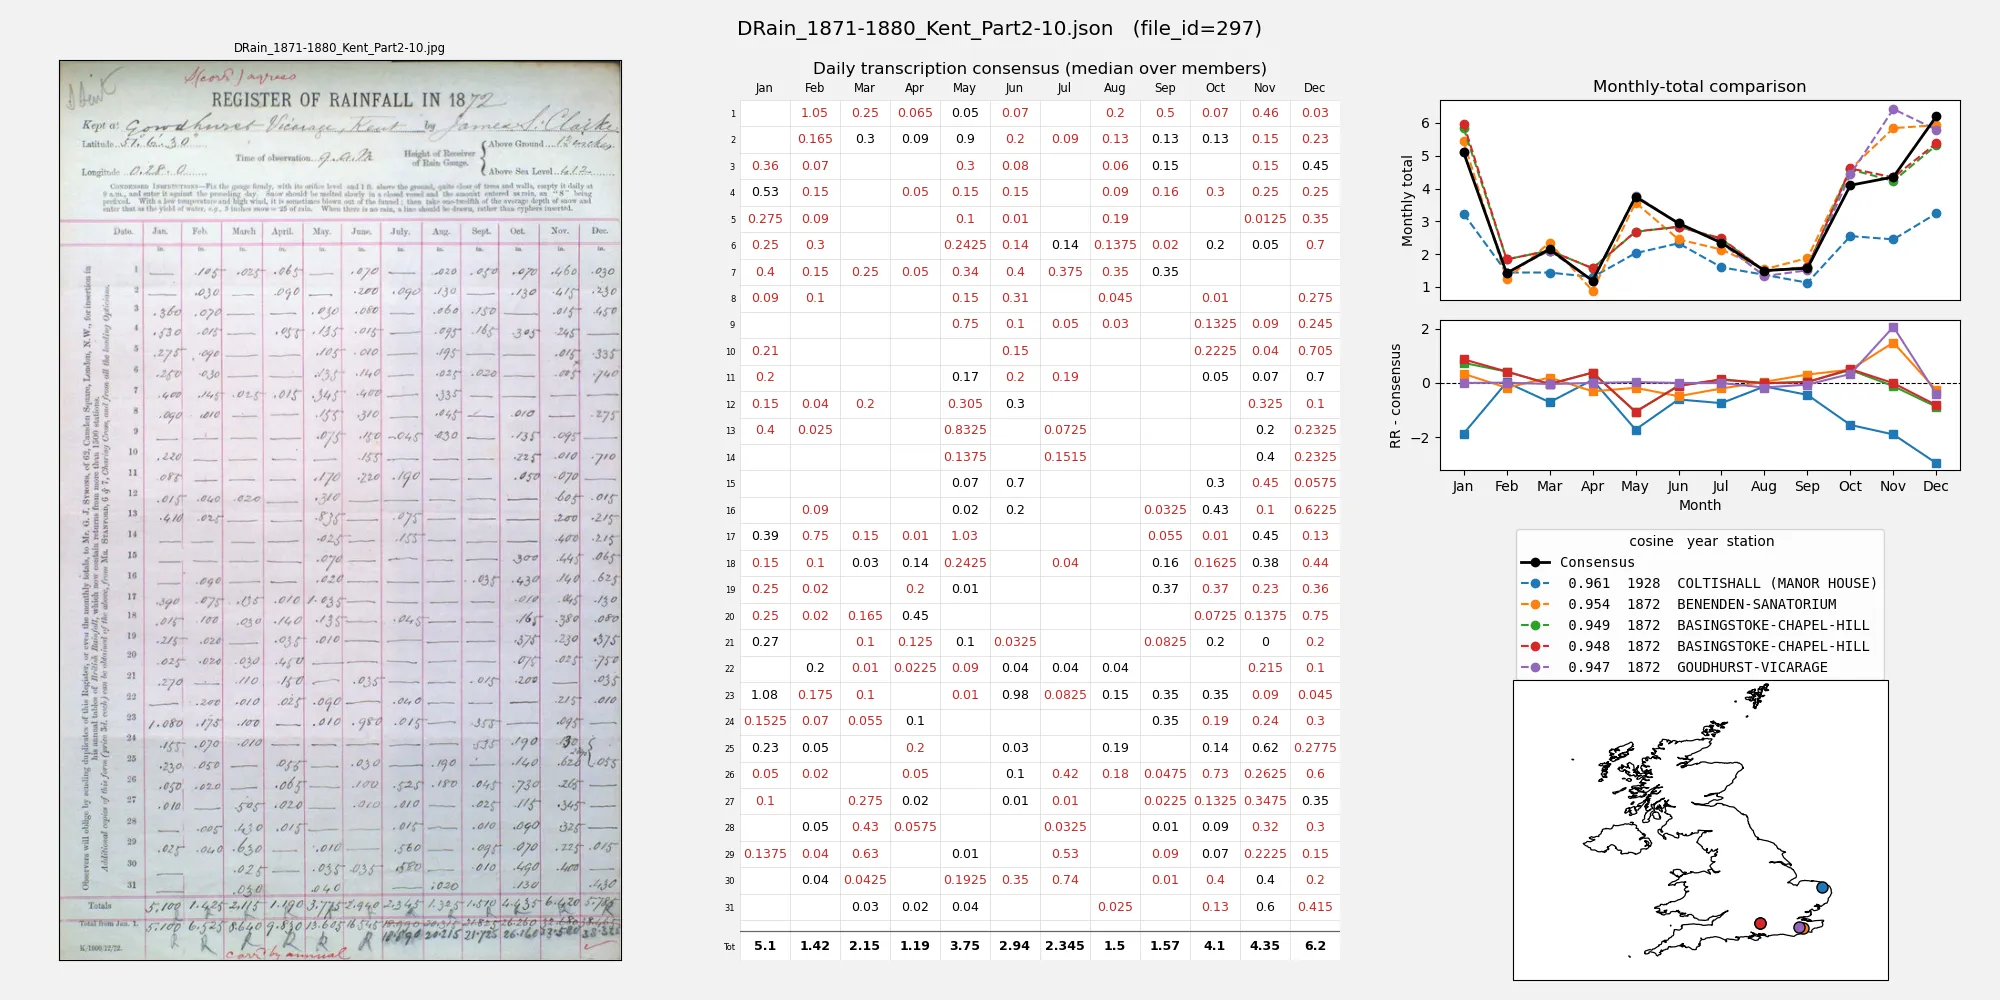

In [25]:
# Demonstrate the diagnostic plot script, rendered inline.

import importlib.util

import src.rainfall_rescue_sqlite as _pkg
from IPython.display import Image, display

# Locate the script relative to the repository root (parent of the src package).
repo_root = Path(_pkg.__file__).resolve().parents[2]
script_path = repo_root / "scripts" / "diagnostics" / "plot_image_consensus_metadata.py"

spec = importlib.util.spec_from_file_location("diag_plot", script_path)
diag_plot = importlib.util.module_from_spec(spec)
spec.loader.exec_module(diag_plot)

specifier = "DRain_1871-1880_Kent_Part2-10"
output_path = Path(f"{os.getenv('PDIR')}/diagnostics/{specifier}_diagnostic.webp")

diag_plot.build_figure(
    specifier=specifier,
    ensemble_db=ensemble_db_path,
    comparison_db=comparison_db_path,
    top_k=5,
    output_path=output_path,
)

display(Image(filename=str(output_path)))